In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 8** - maximizing 8D black-box function

- Here we are optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown.

- **Objective** - find the parameter combination that maximises the function’s output, such as _performance_, _efficiency_ or _validation accuracy_.
  - Because the function is high-dimensional and likely complex, global optimisation is hard, so **identifying strong local maxima** is often a practical strategy.

- **For example**, imagine you’re tuning an ML model with eight hyperparameters:
  - learning rate
  - batch size
  - number of layers
  - dropout rate
  - regularisation strength
  - activation function (numerically encoded)
  - optimiser type (encoded)
  - initial weight range.

Each input set returns a single validation accuracy score between 0 and 1.

- **Input** - 8D (40,8)
- **Output** - 8D (40,)
- **Goal** - maximise this score

In [2]:
X = np.load('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

In [3]:
# New data from Week 3 (Function 8)
X_w3_new_point = np.array([0.117464, 0.226763, 0.160734, 0.103849, 0.998846, 0.763666, 0.087753, 0.474624], dtype=np.float64)
Y_w3_new_point = np.array([9.8724734906004], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w3_new_point.reshape(1, -1)))
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
Y_updated = np.append(Y, Y_w3_new_point)[unique_indices]

# Save the updated arrays
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

In [4]:
# Show updated arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  0.92123758 0.67475276]
 [0.117464   0.226763   0.160734   0.103849   0.998846   0.763666
  0.087753   0.474624  ]
 [0.1435503  0.93741452 0.23232482 0.00904349 0.41457893 0.40932517
  0.55377852 0.2058408 ]
 [0.14512029 0.11932754 0.42088822 0.38760861 0.15542283 0.87517163
  0.51055967 0.72861058]
 [0.17615002 0.29396143 0.97567997 0.79393631 0.92340076 0.03084229
  0.80325452 0.59589758]
 [0.17800696 0.56622265 0.99486184 0.210

### **Interpretation of the Output**

- I think I have found a strong signal ($9.87$). 
    - In an 8D real-world context, this usually means several of my variables are in sync.
    
- The Gaussian Process now has a Center of Gravity. 
    - Because 8D is so sparse, the model will want to predict values near $9.87$ only in the immediate vicinity of my coordinates and revert to the global mean everywhere else.
    
I think moving forward I need to test the Robustness of this peak. Is it noise or overfiting or actually a true optimum?

### **Bayesian Optimisation** - Gaussian Processes

- Since the last weeks output for very strong I am choosing to keep the model the same.
    - The only change I am making is increasing the n_resarts_optimizer = 50`, this is because for such a high dimension according to research this is a good quality to have.

In [5]:
kernel = Matern(
    length_scale=[0.5]*8,
    nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5,
    n_restarts_optimizer=50, 
    normalize_y=True,
    random_state=42
)

model.fit(X_unique, Y_updated)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","Matern(length... 0.5], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-05
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",50
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:

### **Acquisition Function** - Expected Improvement (EI)
I have only made one small change of icnreasing the x0 
- $\xi = 0.05$
    - Since I have a strong baseline ($9.87$), I want to be surgical.
    - I use a lower jitter ($\xi=0.05$) than before. However, I want to find points that are statistically likely to beat $9.87$. 
        - In 8D, UCB would likely send us to a random empty corner; EI will keep us focused on the neighborhood of success while still allowing for jumps if a distant area shows high potential.

In [12]:
def expected_improvement(X, model, y_max, xi=0.05):
    mu, sigma = model.predict(X, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0] = 0.0
    return ei.ravel()

x_grid = np.random.uniform(0, 1, size=(300000, 8))
ei_values = expected_improvement(x_grid, model, 9.872473)
next_query = x_grid[np.argmax(ei_values)]

print(f"Strategic 8D Query: {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}")

Strategic 8D Query: 0.110613-0.166799-0.129222-0.228937-0.996353-0.475272-0.301970-0.476277


If your next result is significantly lower (e.g., $1.0$), it means the $9.87$ was a very narrow "needle." If it's higher (e.g., $15.0+$), you've found a broad manifold. Trust the EI to distinguish between the two.

### **Visualisation of Dimensional Importance**

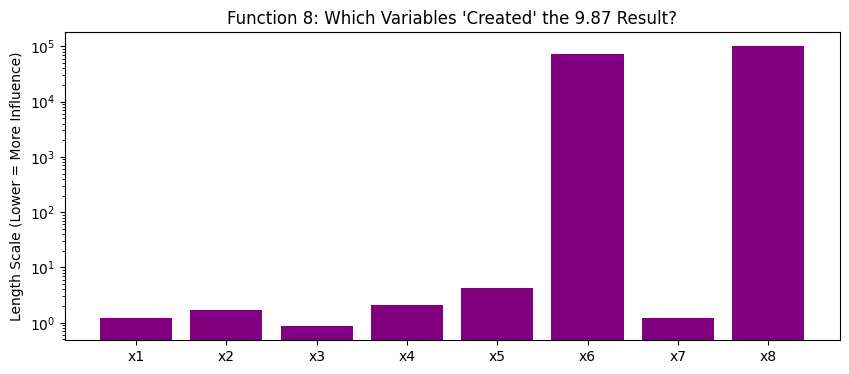

In [11]:
# Shorter bars = More important variables
# Long bars = Variables the model is ignoring
optimised_lengths = model.kernel_.get_params()['length_scale']
plt.figure(figsize=(10, 4))
plt.bar([f'x{i+1}' for i in range(8)], optimised_lengths, color='purple')
plt.yscale('log')
plt.title("Function 8: Which Variables 'Created' the 9.87 Result?")
plt.ylabel("Length Scale (Lower = More Influence)")
plt.show()